# Exploratory Data Analysis

# Imports

In [2]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import inspection

# Env

In [4]:
target_col="class"

# Load data

In [5]:
cols = ['checking_status','duration','credit_history','purpose','credit_amount',
        'savings_status','employment','installment_commitment','personal_status',
        'other_parties','residence_since','property_magnitude','age',
        'other_payment_plans','housing','existing_credits','job',
        'num_dependents','own_telephone','foreign_worker','class']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

df = pd.read_csv(url, sep=' ', header=None, names=cols)
print("shape:", df.shape)

shape: (1000, 21)


In [6]:
inspection.describe_cols(df)

shape df: (1000, 21)

column                    dtype        n_nulls  n_unique
--------------------------------------------------------
age                       int64              0         -
checking_status           str                0         4
class                     int64              0         -
credit_amount             int64              0         -
credit_history            str                0         5
duration                  int64              0         -
employment                str                0         5
existing_credits          int64              0         -
foreign_worker            str                0         2
housing                   str                0         3
installment_commitment    int64              0         -
job                       str                0         4
num_dependents            int64              0         -
other_parties             str                0         3
other_payment_plans       str                0         3
own_telep

# Split

In [15]:
features = df.columns.drop(target_col)
X = df[features]
y = df[target_col]

# Target

unique values: [1 2]
mean: 1.3


,count,pct
class,,
1,700,0.7
2,300,0.3


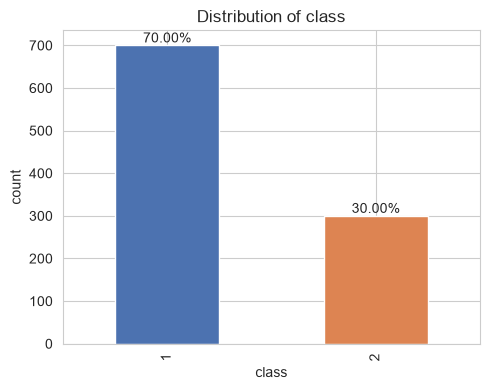

In [16]:
print("unique values:", y.unique())
print("mean:", y.mean())

counts = y.value_counts()
pct = y.value_counts(normalize=True).round(4)
dist = pd.concat([counts, pct], axis=1)
dist.columns = ['count', 'pct']
display(dist)

fig, ax = plt.subplots(figsize=(5, 4))
dist['count'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
for i, (c, p) in enumerate(zip(dist['count'], dist['pct'])):
    ax.text(i, c, f"{p*100:.2f}%", ha='center', va='bottom')
ax.set_title(f"Distribution of {target_col}")

ax.set_ylabel("count")
plt.tight_layout()
plt.show()

# Features distribution

In [17]:
numeric_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(exclude="number").columns

## Numeric features

In [21]:
decile_table

,count,mean,std,min,1%,5%,10%,20%,30%,40%,50%,60%,70%,80%,90%,95%,99%,max
duration,1000.0,20.903,12.058814,4.0,6.00,6.00,9.0,12.0,12.0,15.0,18.0,24.0,24.0,30.0,36.0,48.0,60.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,425.83,708.95,932.0,1262.0,1479.4,1906.8,2319.5,2852.4,3590.0,4720.0,7179.4,9162.7,14180.39,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,1.00,1.00,1.0,2.0,2.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,1.00,1.00,1.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,20.00,22.00,23.0,26.0,28.0,30.0,33.0,36.0,39.0,45.0,52.0,60.0,67.01,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,3.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.00,2.0


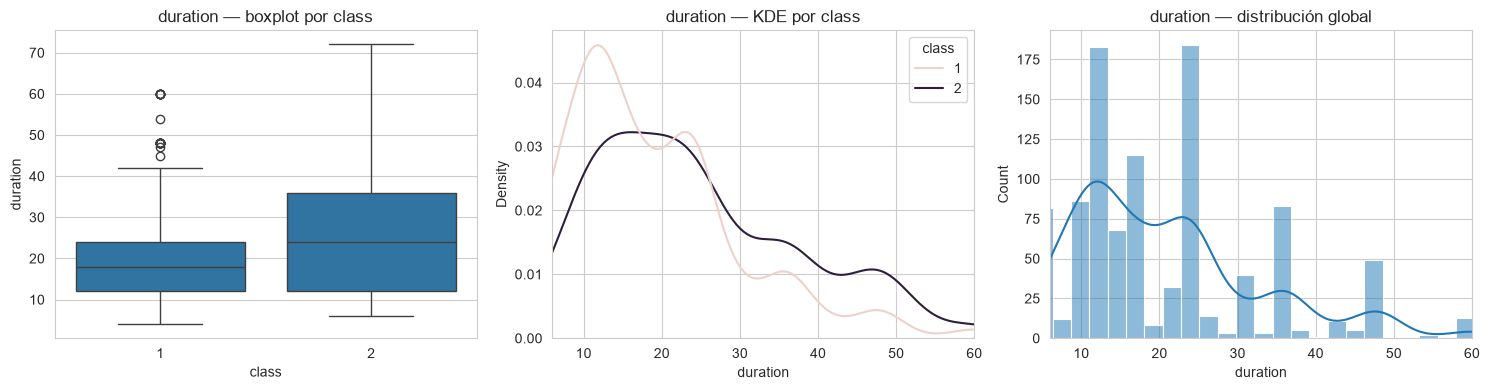

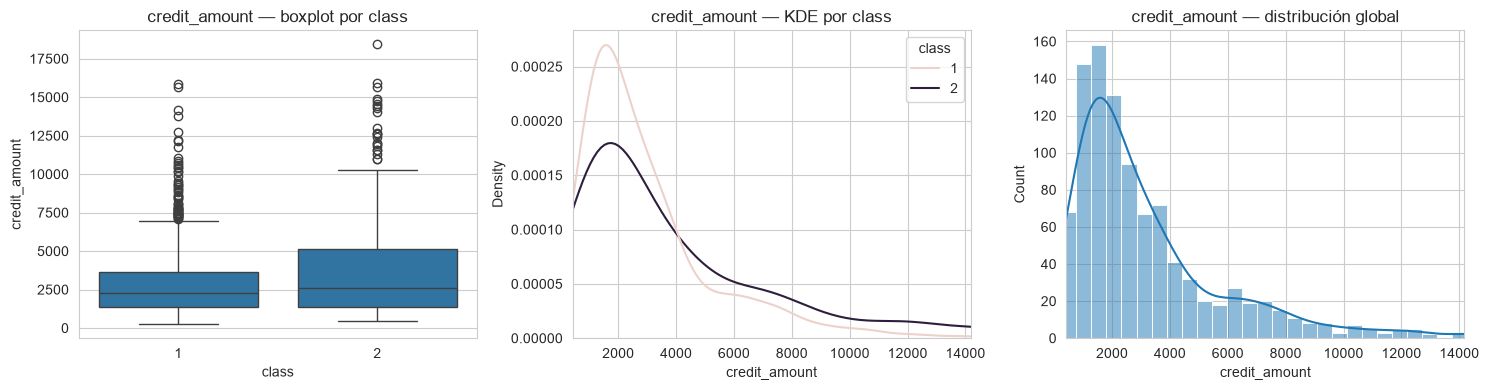

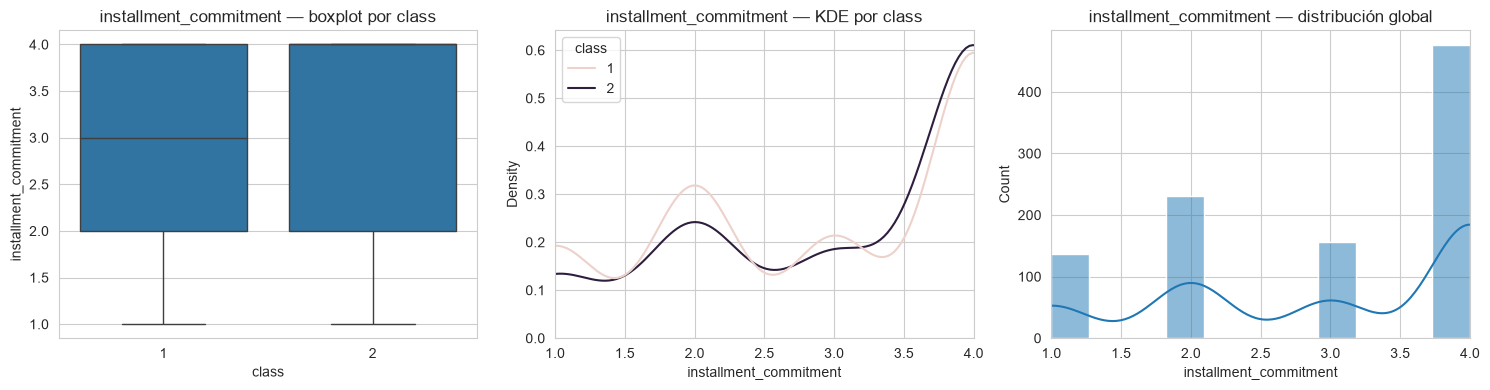

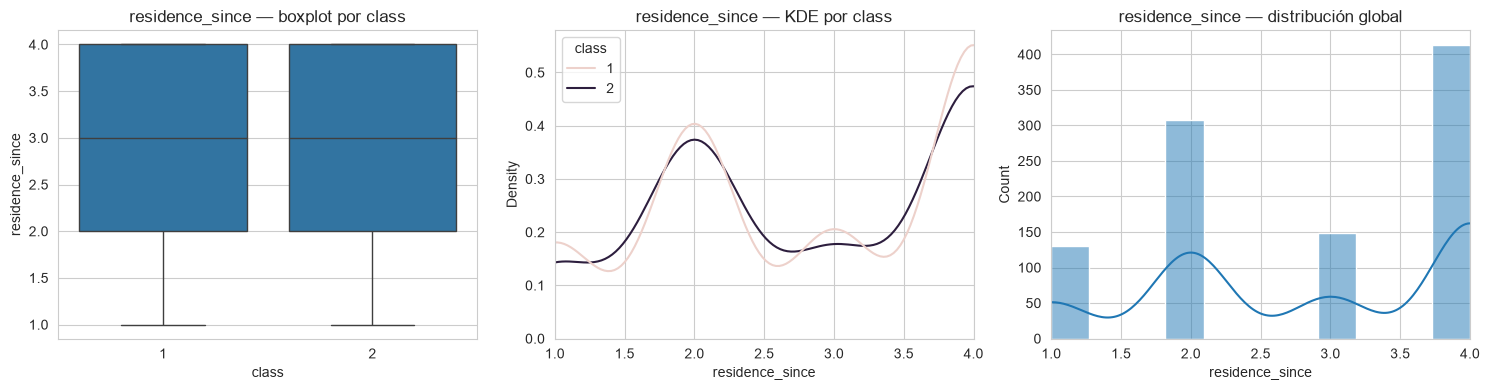

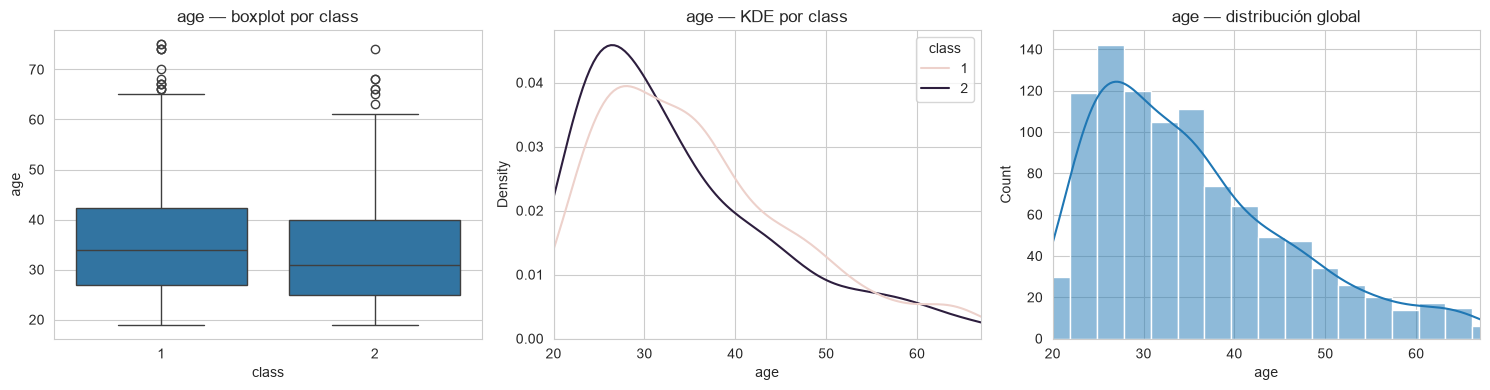

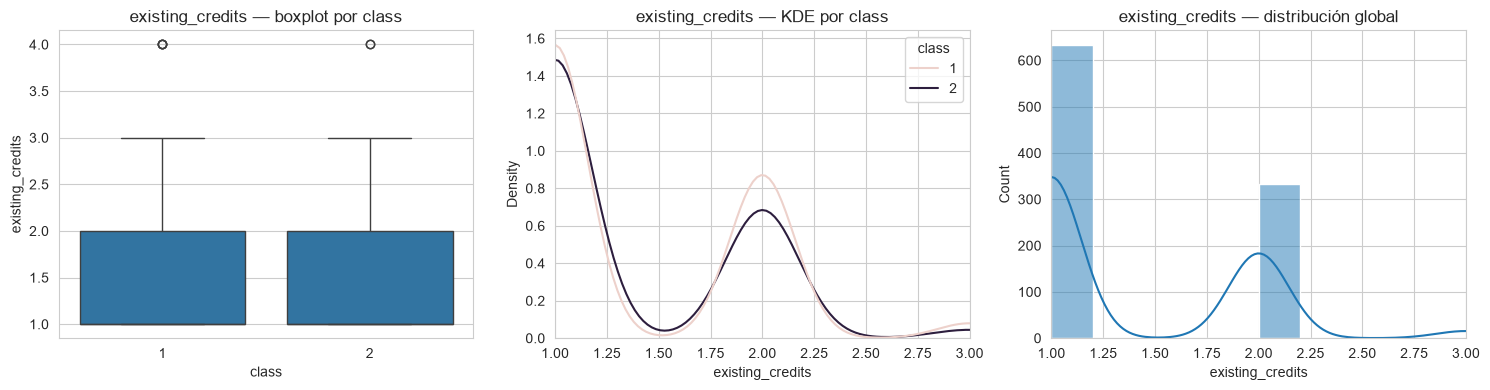

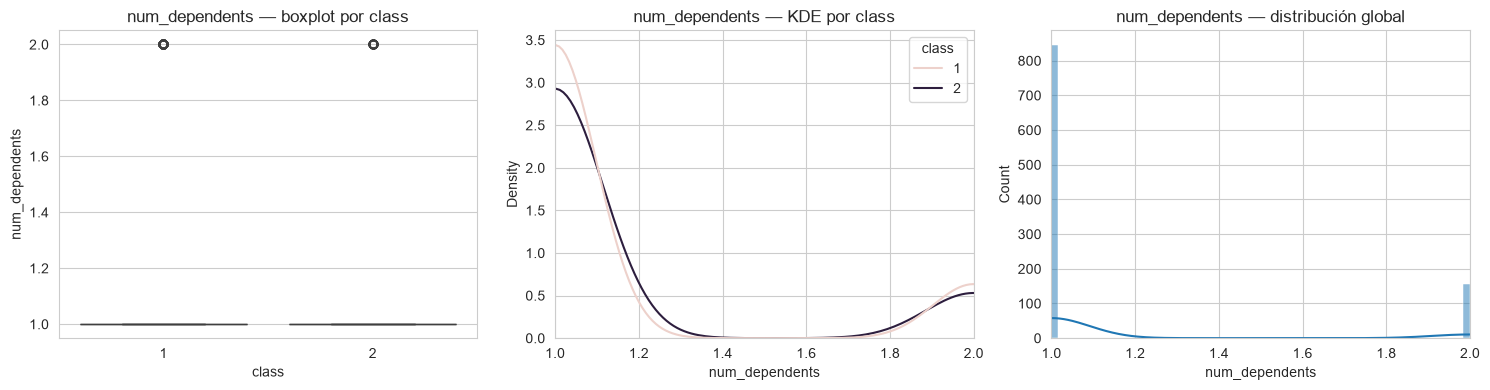

In [20]:
for col in numeric_features:
    p01, p99 = decile_table.loc[col, ["1%", "99%"]]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.boxplot(x=target_col, y=col, data=df, ax=axes[0])
    axes[0].set_title(f"{col} — boxplot por {target_col}")

    sns.kdeplot(data=df, x=col, hue=target_col, common_norm=False, ax=axes[1])
    axes[1].set_xlim(p01, p99)
    axes[1].set_title(f"{col} — KDE por {target_col}")

    sns.histplot(data=df, x=col, kde=True, ax=axes[2])
    axes[2].set_xlim(p01, p99)
    axes[2].set_title(f"{col} — distribución global")

    plt.tight_layout()
    plt.show()

## Categorical features